## AutoGluon

<div style="text-align: center;"><img src=".//Images//autoGluon.png" alt="AutoGluon" width="200" height="200" style="margin: 10px; "/></div>

**AutoGluon** to otwartoźródłowa biblioteka stworzona przez Amazon, która upraszcza proces trenowania modeli uczenia maszynowego dzięki podejściu **AutoML** (automated machine learning). Została zaprojektowana z myślą o maksymalnej **łatwości użycia**, **wydajności** i **elastyczności**, co czyni ją atrakcyjnym wyborem zarówno dla początkujących, jak i zaawansowanych użytkowników.

---

**Główne cechy AutoGluon**

* **Minimalny kod** – wystarczy kilka linijek, by uzyskać dobry model.
* **Automatyczne stackowanie modeli** (ensemble learning).
* **Obsługa brakujących danych i danych kategorycznych** bez potrzeby manualnego czyszczenia.
* **Obsługa różnych typów zadań**:

  * klasyfikacja,
  * regresja,
  * klasyfikacja wieloetykietowa,
  * tabular, obraz i tekst.

**Wspierane algorytmy i techniki:**

AutoGluon automatycznie stosuje wiele modeli bazowych i technik ensemble, w tym:

* LightGBM (Gradient Boosting Trees)
* CatBoost (Gradient Boosting dla danych kategorycznych)
* XGBoost (opcjonalnie)
* ExtraTrees (Random Forest z losowym podziałem)
* K Nearest Neighbors (KNN)
* Neural Networks (MXNet / pytorch)
* FastAI tabular models
* TabularNN (AutoGluon-specific sieć neuronowa)
* Random Forest (sklearn)
* Linear Models (Logistic Regression, Ridge, Lasso)
* Stacked Ensemble (bagging + multi-level stacking)
* Greedy Ensemble Selection (optymalizacja kombinacji modeli)
* Feature pruning, selection, encoding
* Hyperparameter Optimization (HPO)
* Automated feature engineering (encoding, missing imputation, normalization)

> Uwaga: lista modeli może się różnić w zależności od wersji i konfiguracji (presets, hyperparameters).

---

**Instalacja**

```bash
pip install autogluon
```

Rozmiar: ok. **600 MB** (zależnie od środowiska – zawiera LightGBM, CatBoost, MXNet/PyTorch itp.)

Strona:
[https://auto.gluon.ai/](https://auto.gluon.ai/)

---

**Licencja**

AutoGluon jest objęty licencją **Apache License 2.0**, która:

* umożliwia dowolne (w tym komercyjne) użycie i modyfikację,
* wymaga zachowania informacji o licencji i autorach,
* nie udziela gwarancji – używasz na własne ryzyko.

Warunek cytowania (https://github.com/autogluon/autogluon/blob/master/CITING.md):
* Erickson, Nick i in. „AutoGluon-Tabular: solidny i dokładny AutoML dla danych strukturalnych”. Wydanie wstępne arXiv arXiv:2003.06505 (2020).

---

**Źródła:**

* [https://auto.gluon.ai/stable/index.html](https://auto.gluon.ai/stable/index.html)
* [https://github.com/autogluon/autogluon](https://github.com/autogluon/autogluon)
* [https://towardsdatascience.com/automl-with-autogluon-transform-your-ml-workflow-with-just-four-lines-of-code-1d4b593be129/](https://towardsdatascience.com/automl-with-autogluon-transform-your-ml-workflow-with-just-four-lines-of-code-1d4b593be129/)

---

**Podstawowy przykład (klasyfikacja)**

```python
from autogluon.tabular import TabularPredictor

# Wczytanie danych
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer(as_frame=True)
df = data.frame
df['target'] = data.target

# Podział na trening i test
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

# Uczenie modelu
predictor = TabularPredictor(label='target').fit(train_data)

# Predykcja i ocena
preds = predictor.predict(test_data)
performance = predictor.evaluate(test_data)
```

**Uwaga**: *częśc kodu jest jako markdown, aby nie uruchomić przypadkowo :)  żmudnych obliczeń.*

---

**Co dzieje się „pod maską”?**

AutoGluon:

* wybiera wiele modeli bazowych (np. LightGBM, CatBoost, NN),
* testuje różne hiperparametry,
* tworzy zestawy modeli (ensemble),
* monitoruje i optymalizuje metryki (np. accuracy, ROC-AUC).


## Przygotowanie danych

<div style="text-align: center;"><img src=".//Images//Bank.png" alt="Bank" width="400" height="120" style="margin: 10px; "/></div>

Wykorzystamy zbiór danych z UCI, opisujący kampanię marketingową banku, w której klientom oferowano lokatę terminową. Zmienna docelowa to „yes”, jeśli klient zgodził się na lokatę, i „no”, jeśli nie.

Źródło: https://archive.ics.uci.edu/dataset/222/bank+marketing

*Szerszy opis można znaleźć w materiałach ze spotkania o **Strojeniu modeli**.*

# Tworzenie modeli

In [15]:
from autogluon.tabular import TabularPredictor
import pandas as pd

In [19]:
# Wczytanie danych z pliku CSV
df = pd.read_csv('./Data/bank-additional-full.csv', sep=';')
df = df.drop(columns='duration')

# Sprawdzenie kolumn i typów danych
print(df.dtypes)
print(df['y'].value_counts())

# Zakładamy, że kolumna 'y' to etykieta (czy klient otworzył lokatę: yes/no)
# Zamieniamy na 0/1 dla spójności
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Podział na trening i test
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

# Trenowanie modelu
predictor = TabularPredictor(
    label='y',
    eval_metric='roc_auc', # accuracy, roc_auc, f1, log_loss (domyślnie), balanced_accuracy i inne/
).fit(  
    train_data = train_data,
    time_limit=60,
    presets='experimental_quality' # best_quality i inne
) 

# Jeśli ustawisz zarówno presets, jak i time_limit, 
# AutoGluon będzie starał się osiągnąć jakość zdefiniowaną przez presets, 
# ale przerwie po określonym czasie.

# Ocena modelu
predictor.evaluate(test_data)

No path specified. Models will be saved in: "AutogluonModels\ag-20250517_170220"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.3
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          8
Memory Avail:       16.70 GB / 31.84 GB (52.5%)
Disk Space Avail:   20.53 GB / 475.63 GB (4.3%)
Presets specified: ['experimental_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then 

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
y
no     36548
yes     4640
Name: count, dtype: int64


Leaderboard on holdout data (DyStack):
                   model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val  fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      LightGBMXT_BAG_L1       0.819512   0.794407     roc_auc        1.815980       0.376439  4.587868                 1.815980                0.376439           4.587868            1       True          3
1    WeightedEnsemble_L2       0.819512   0.794407     roc_auc        1.815980       0.381459  4.953108                 0.000000                0.005020           0.365240            2       True          4
2    WeightedEnsemble_L3       0.819512   0.794407     roc_auc        1.822411       0.381565  4.938952                 0.006430                0.005126           0.351085            3       True          5
3  KNeighborsUnif_BAG_L1       0.741067   0.724412     roc_auc        0.113024       0.637514  0.073214                 0.113024     

{'roc_auc': 0.8078574198514814,
 'accuracy': 0.8991260014566642,
 'balanced_accuracy': 0.6002513413554201,
 'mcc': 0.3501065206089448,
 'f1': 0.3260340632603406,
 'precision': 0.7052631578947368,
 'recall': 0.2120253164556962}

# Rezultaty

In [28]:
print("AutoGluon rozpoznał typ problemu jako: ", predictor.problem_type)
print("AutoGluon zidentyfikował następujące typy cech:")
print(predictor.feature_metadata)

AutoGluon infers problem type is:  binary
AutoGluon identified the following types of features:
('category', [])  : 9 | ['job', 'marital', 'education', 'default', 'housing', ...]
('float', [])     : 5 | ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
('int', [])       : 4 | ['age', 'campaign', 'pdays', 'previous']
('int', ['bool']) : 1 | ['contact']


In [30]:
predictor.model_best

'WeightedEnsemble_L2'

In [31]:
predictor.evaluate(test_data)

C:\Users\ksmol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'roc_auc': 0.8010028331973167,
 'accuracy': 0.8849235251274581,
 'balanced_accuracy': 0.5,
 'mcc': 0.0,
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0}

# Predykcja z prawdopodobieństwami

In [20]:
# Predykcja klas
pred_labels = predictor.predict(test_data)

# Predykcja prawdopodobieństw
pred_proba = predictor.predict_proba(test_data)
# predict_proba zwraca DataFrame z prawdopodobieństwami przynależności do każdej klasy (0 i 1).

# Wyświetlenie kilku wyników
print(pred_proba.head())

           0         1
2   0.962022  0.037978
9   0.959942  0.040058
10  0.963504  0.036496
12  0.958725  0.041275
16  0.961486  0.038514


# Wyjaśnianie modelu – znaczenie cech (feature importance)

In [21]:
# Wyznaczanie ważności cech
importance_df = predictor.feature_importance(test_data)

# Wyświetlenie wyników
print(importance_df)

Computing feature importance via permutation shuffling for 19 features using 5000 rows with 5 shuffle sets...
	30.05s	= Expected runtime (6.01s per shuffle set)
	15.36s	= Actual runtime (Completed 5 of 5 shuffle sets)


                importance    stddev   p_value  n  p99_high   p99_low
nr.employed       0.038348  0.004573  0.000024  5  0.047764  0.028933
month             0.032409  0.002823  0.000007  5  0.038221  0.026597
contact           0.018458  0.004032  0.000257  5  0.026760  0.010157
emp.var.rate      0.014717  0.004922  0.001302  5  0.024852  0.004582
euribor3m         0.011120  0.004546  0.002717  5  0.020479  0.001761
campaign          0.003981  0.001082  0.000595  5  0.006209  0.001753
pdays             0.003453  0.001584  0.004094  5  0.006713  0.000192
day_of_week       0.002089  0.001395  0.014299  5  0.004961 -0.000783
cons.conf.idx     0.002034  0.001997  0.042480  5  0.006146 -0.002077
poutcome          0.002022  0.002332  0.062236  5  0.006824 -0.002779
age               0.001557  0.001254  0.024978  5  0.004139 -0.001024
job               0.001058  0.001016  0.040182  5  0.003149 -0.001033
default           0.001035  0.000956  0.036379  5  0.003004 -0.000934
cons.price.idx    0.

AutoGluon wykorzystuje metodę podobną do SHAP – wpływ usunięcia cechy na wynik modelu.

Wynik to tabela, która pokazuje:

* importance – jak bardzo dana cecha wpływa na predykcję,
* stddev – odchylenie standardowe (pewność),
* p_value – istotność statystyczna (czy wpływ jest przypadkowy),
* n – liczba powtórzeń permutacji (shuffle sets), domyślnie n=5, użytych do estymacji,
* p99_high - 99. percentyl wpływu cechy – górna granica wpływu wśród powtórzeń,
* p99_low - 1. percentyl wpływu cechy – dolna granica wpływu wśród powtórzeń.

# Wizualizacja znaczenia cech (opcjonalna)

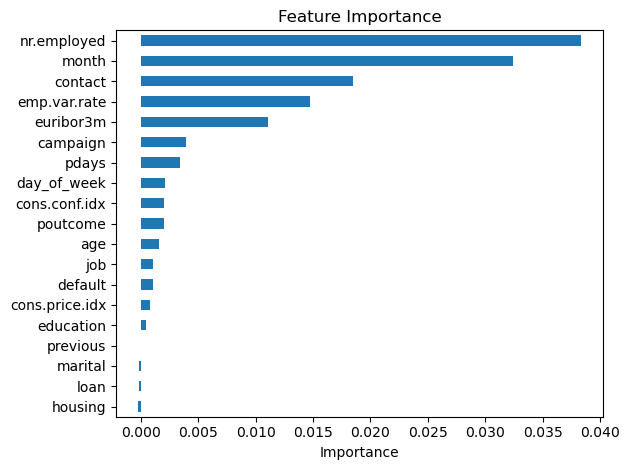

In [22]:
import matplotlib.pyplot as plt

importance_df['importance'].plot(kind='barh')
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Porównanie modeli bazowych (leaderboard)

In [25]:
# Porównanie modeli w ensemble
leaderboard = predictor.leaderboard(test_data, silent=True)

#
print(f"Metryka:{predictor.eval_metric}")

# Wyświetlenie
print(leaderboard[['model', 'score_val', 'score_test', 'pred_time_test', 'fit_time']])

Metryka:roc_auc
                   model  score_val  score_test  pred_time_test   fit_time
0        LightGBM_BAG_L1   0.802707    0.810002        0.125997   4.886354
1    WeightedEnsemble_L2   0.803313    0.807857        0.387584  12.730069
2    WeightedEnsemble_L3   0.803313    0.807857        0.387584  12.565440
3      LightGBMXT_BAG_L1   0.799704    0.798901        0.261587   7.283425
4  KNeighborsUnif_BAG_L1   0.723290    0.727939        0.204034   0.159844
5  KNeighborsDist_BAG_L1   0.702043    0.710304        0.182281   0.157366


To pozwala:

* zobaczyć który model był najlepszy (WeightedEnsemble),
* poznać metryki walidacyjne i testowe,
* ocenić szybkość trenowania i predykcji.

## Najważniejsze parametry

Podczas uruchamiania AutoGluon (TabularPredictor.fit(...)) możesz dostosować wiele parametrów, które mają istotny wpływ na **dokładność**, **czas treningu** i **dopasowanie do problemu**. Poniżej znajdziesz najważniejsze z nich z wyjaśnieniem:

**1. `time_limit`**

**Opis**: limit czasu (w sekundach) dla całego procesu trenowania.
**Przykład**:

```python
predictor.fit(train_data, time_limit=600)  # 10 minut
```

---

**2. `presets`**

**Opis**: gotowe ustawienia szybkości/dokładności.
**Najczęstsze opcje**:

* `"best_quality"` – najwyższa jakość (wolne)
* `"high_quality_fast_inference_only_refit"` – balans między jakością i czasem
* `"medium_quality_faster_train"` – szybszy trening
* `"fastest"` – minimalny czas

**Przykład**:

```python
predictor.fit(train_data, presets="best_quality")
```

---

**3. `hyperparameters`**

**Opis**: pozwala określić, które modele mają być użyte i z jakimi ustawieniami.
**Przykład – tylko LightGBM i CatBoost**:

```python
predictor.fit(train_data, hyperparameters={
    'GBM': {},
    'CAT': {}
})
```

**Zaawansowany przykład – strojenie**:

```python
predictor.fit(train_data, hyperparameters={
    'GBM': {'extra_trees': True, 'ag_args': {'name_suffix': 'XT'}},
    'NN_TORCH': {'num_layers': 2},
    'RF': {'criterion': 'gini'}
})
```

---

**4. `excluded_model_types`**

**Opis**: modele, które mają być pominięte.
**Przykład**:

```python
predictor.fit(train_data, excluded_model_types=['KNN', 'NN_TORCH'])
```

---

**5. `num_bag_folds` / `num_stack_levels`**

**Opis**: kontrolują głębokość ensemble i stackingu.

* `num_bag_folds=5` – poprawia jakość (kosztem czasu),
* `num_stack_levels=1` – włącza stacking (0 = wyłączony).

**Przykład**:

```python
predictor.fit(train_data, num_bag_folds=5, num_stack_levels=1)
```

---

**Przykład: trenowanie pod wysoką jakość**

```python
predictor = TabularPredictor(label='target')
predictor.fit(
    train_data,
    presets='best_quality',
    time_limit=1800,  # 30 minut
    num_bag_folds=5,
    num_stack_levels=2
)
```

---

# Export i import modeli

## Eksport modelu (zapis do katalogu)

Po treningu zapisujesz cały obiekt `TabularPredictor`:

```python
# Ścieżka, gdzie zapiszesz model
save_path = "autogluon_model"

# Trenowanie i zapis automatyczny
predictor = TabularPredictor(label='target', path=save_path).fit(train_data)
```

> Domyślnie `fit()` zapisuje model w katalogu wskazanym przez `path`. Jeśli nie podasz `path`, zapisywane będzie do katalogu tymczasowego.

Możesz też później wymusić zapis:

```python
predictor.save()  # zapisuje do ścieżki zdefiniowanej przy tworzeniu
```

---

## Import modelu (załadowanie z dysku)

Wczytanie modelu z katalogu:

```python
from autogluon.tabular import TabularPredictor

# Ścieżka, gdzie wcześniej zapisano model
load_path = "autogluon_model"

# Wczytanie
loaded_predictor = TabularPredictor.load(load_path)
```

---

## Użycie wczytanego modelu

```python
# Predykcja etykiet
preds = loaded_predictor.predict(test_data)

# Predykcja prawdopodobieństw
probs = loaded_predictor.predict_proba(test_data)

# Ewaluacja
loaded_predictor.evaluate(test_data)
```

# W skrócie

Oto **skrócony kod** do uruchomienia AutoGluon i oceny modelu na zbiorze *Bank Marketing* z UCI:

In [26]:
# 1. Inicjalizacja
from autogluon.tabular import TabularPredictor
import pandas as pd

# 2. Wczytanie danych
df = pd.read_csv('./Data/bank-additional-full.csv', sep=';')
df = df.drop(columns='duration')
df['y'] = df['y'].map({'no': 0, 'yes': 1})  # klasy binarne: 0/1

# Podział na train/test
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

# 3. Trening AutoML
predictor = TabularPredictor(label='y', eval_metric='roc_auc').fit(
    train_data,
    time_limit=60,  # maks. czas treningu (sekundy)
    presets='best_quality',
    verbosity=0 # brak komentarzy
)

# 4. Ocena modelu lidera
performance = predictor.evaluate(test_data)

# 5. Wyjaśnienie modelu – znaczenie cech
importance_df = predictor.feature_importance(test_data)
print(importance_df)

# (Opcjonalnie: confusion matrix i AUC)
from sklearn.metrics import confusion_matrix, roc_auc_score

y_true = test_data['y']
y_pred = predictor.predict(test_data)
y_proba = predictor.predict_proba(test_data)[1]  # prawdopodobieństwo klasy 1

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_proba))

No path specified. Models will be saved in: "AutogluonModels\ag-20250517_171224"
C:\Users\ksmol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                importance    stddev   p_value  n  p99_high   p99_low
month             0.028941  0.003069  0.000015  5  0.035260  0.022621
nr.employed       0.020406  0.005709  0.000664  5  0.032161  0.008651
contact           0.017557  0.004383  0.000430  5  0.026581  0.008532
emp.var.rate      0.015572  0.006487  0.002908  5  0.028928  0.002216
euribor3m         0.009060  0.003868  0.003176  5  0.017025  0.001095
pdays             0.003708  0.001481  0.002497  5  0.006758  0.000659
campaign          0.002955  0.001150  0.002269  5  0.005322  0.000588
poutcome          0.001563  0.002779  0.138467  5  0.007284 -0.004158
default           0.001160  0.000930  0.024649  5  0.003075 -0.000754
cons.conf.idx     0.000609  0.001332  0.182317  5  0.003352 -0.002134
age               0.000600  0.001128  0.149843  5  0.002922 -0.001722
education         0.000585  0.002288  0.299027  5  0.005295 -0.004125
job               0.000481  0.001377  0.239249  5  0.003316 -0.002354
cons.price.idx    0.